In [2]:
import pandas as pd
import numpy as np
from sklearn import *
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/Users/abasar/data/creditcard-fraud.csv")

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [11]:
target = "Class"

y = df[target]
y = label_encoder.fit_transform(y)

X = df.loc[:,"V1":"V28"]
training_size = int(len(X) * 0.7)
X_train = X.values[:training_size]
y_train = y[:training_size]

X_test = X.values[training_size:]
y_test = y[training_size:]

pd.Series(y_test).value_counts()/len(y_test)

0    0.998736
1    0.001264
dtype: float64

In [17]:
pipe = pipeline.Pipeline([
    ("poly", preprocessing.PolynomialFeatures(degree=1, include_bias=False)),
    ("scaler", preprocessing.StandardScaler()),
    ("est", linear_model.LogisticRegression())
])

pipe.fit(X_train, y_train) # train the model

y_train_pred = pipe.predict(X_train)

y_test_pred = pipe.predict(X_test)

print(metrics.confusion_matrix(y_test, y_test_pred))

[[85317    18]
 [   52    56]]


In [13]:
metrics.accuracy_score(y_test, y_test_pred)

0.9991807403766253

In [14]:
metrics.recall_score(y_test, y_test_pred)

0.5185185185185185

In [15]:
metrics.precision_score(y_test, y_test_pred)

0.7567567567567568

Text(0.5, 1.0, 'ROC curve, auc: 0.970')

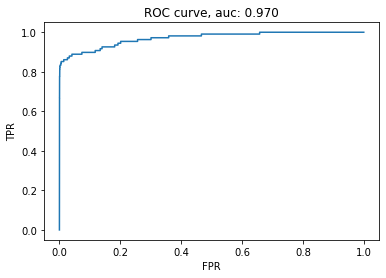

In [16]:
y_test_prob = pipe.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_test_prob)
plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")

auc = metrics.roc_auc_score(y_test, y_test_prob)
plt.title(f"ROC curve, auc: {auc:.3f}")

In [18]:
pd.Series(y).value_counts()

0    284315
1       492
dtype: int64

In [25]:
df_neg = df[y==0].sample(492)
X_neg = df_neg.loc[:, "V1":"V28"].values
y_neg = df_neg[target]
X_neg.shape

(492, 28)

In [26]:
df_pos = df[y==1]
X_pos = df_pos.loc[:, "V1":"V28"].values
y_pos = df_pos[target]
X_pos.shape

(492, 28)

In [27]:
y_test_prob

array([7.17490217e-04, 2.35828728e-05, 5.78847721e-04, ...,
       1.49531161e-04, 8.55912229e-04, 4.32954756e-04])